In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import math, itertools, time
from fractions import Fraction
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

RAIZ = Path(os.path.dirname(os.path.dirname(os.path.abspath(''))))
RES = RAIZ / 'results'
print('repo:', RAIZ.name)

repo: group-count-dynamic


## 2. Greedy local y posterior ala prueba

Fijar T, aplicar la prueba, simular el
conteo, y correr greedy **dentro de T** condicionado a lo observado; el costo C
es cuántas subpruebas usa, promediado sobre el conteo.

T de dos personas: si el conteo es 1, greedy prueba a la
primera; la mitad de las veces la acredita y termina (1 subprueba), la otra
mitad deduce al sano pero aún debe acreditarlo (2 subpruebas). C(T) = 2q(1−q) × 1.5 = 3q(1−q).

Medido así, el costo deja de ser plano: depende de q y de m

In [4]:
def estados_prior(m, q):
    '''Los 2^m estados de T (1 = infectado) con su peso prior.'''
    out = []
    for z in itertools.product((0, 1), repeat=m):
        w = 1.0
        for b in z:
            w *= (1.0 - q) if b else q
        out.append((z, w))
    return out

def subpruebas_greedy_local(z, q, u=1.0):
    '''Subpruebas que greedy usa dentro de T tras la prueba global, estado real z.

    La global revela el conteo de infectados r = sum(z); si r = 0 acredita a todos.
    Despues, greedy elige el subpool de pendientes que maximiza
    S0 = P(todo sano | historia) * tamano (empate: el mas chico, primero en orden
    lexicografico), observa el conteo del subpool, acredita si r = 0,
    y repite hasta que nadie quede pendiente. Hard clearing: la deduccion informa
    pero solo una prueba limpia (conteo 0) acredita.
    '''
    m, r_global = len(z), sum(z)
    if r_global == m or r_global == 0:
        return 0
    belief = [(s, w) for s, w in estados_prior(m, q) if sum(s) == r_global]
    acreditados, n_sub = set(), 0
    while True:
        tot = sum(w for _, w in belief)
        p_sano = [sum(w for s, w in belief if not s[i]) / tot for i in range(m)]
        pend = [i for i in range(m) if i not in acreditados and p_sano[i] > 1e-12]
        if not pend:
            return n_sub
        mejor, mejor_s0 = None, -1.0
        for k in range(1, len(pend) + 1):
            for T in combinations(pend, k):
                p_all = sum(w for s, w in belief if all(not s[i] for i in T)) / tot
                s0 = p_all * k * u
                if s0 > mejor_s0 + 1e-12:
                    mejor, mejor_s0 = T, s0
        r = sum(z[i] for i in mejor)
        n_sub += 1
        belief = [(s, w) for s, w in belief if sum(s[i] for i in mejor) == r]
        if r == 0:
            acreditados.update(mejor)

def costo_local_exacto(m, q):
    '''C(T) exacto por enumeracion: esperanza de subpruebas sobre los 2^m estados.'''
    return sum(w * subpruebas_greedy_local(z, q) for z, w in estados_prior(m, q))

# Autoverificacion 1: la forma cerrada del micro-caso m=2.
for q in (0.15, 0.30, 0.45, 0.70):
    assert abs(costo_local_exacto(2, q) - 3 * q * (1 - q)) < 1e-12
print('OK: C(T) exacto coincide con la forma cerrada 3q(1-q) en m=2')

# Autoverificacion 2: Monte Carlo sembrado contra la enumeracion exacta.
from augmented.provenance import seeded_rng
rng = seeded_rng(20260821)
m_chk, q_chk, n_sim = 4, 0.30, 4000
muestras = [subpruebas_greedy_local(tuple(int(rng.random() >= q_chk) for _ in range(m_chk)), q_chk)
            for _ in range(n_sim)]
mc, se = np.mean(muestras), np.std(muestras, ddof=1) / np.sqrt(n_sim)
exacto = costo_local_exacto(m_chk, q_chk)
assert abs(mc - exacto) < 4 * se, (mc, exacto, se)
print(f'OK: Monte Carlo {mc:.3f} +- {se:.3f} coincide con el exacto {exacto:.3f}')

OK: C(T) exacto coincide con la forma cerrada 3q(1-q) en m=2


OK: Monte Carlo 2.053 +- 0.024 coincide con el exacto 2.094


In [5]:
filas = []
for q in (0.15, 0.30, 0.45):
    for m in (2, 3, 4, 5):
        c = costo_local_exacto(m, q)
        filas.append({'q': q, 'personas': m,
                      'subpruebas tras la global': c,
                      'total con la global': 1 + c,
                      'costo global viejo': float(m)})
nuevo = pd.DataFrame(filas)
print(nuevo.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

     q  personas  subpruebas tras la global  total con la global  costo global viejo
0.1500         2                     0.3825               1.3825              2.0000
0.1500         3                     0.7841               1.7841              3.0000
0.1500         4                     1.2645               2.2645              4.0000
0.1500         5                     1.8207               2.8207              5.0000
0.3000         2                     0.6300               1.6300              2.0000
0.3000         3                     1.3230               2.3230              3.0000
0.3000         4                     2.0937               3.0937              4.0000
0.3000         5                     2.9232               3.9232              5.0000
0.4500         2                     0.7425               1.7425              2.0000
0.4500         3                     1.5964               2.5964              3.0000
0.4500         4                     2.5140               3.5140 

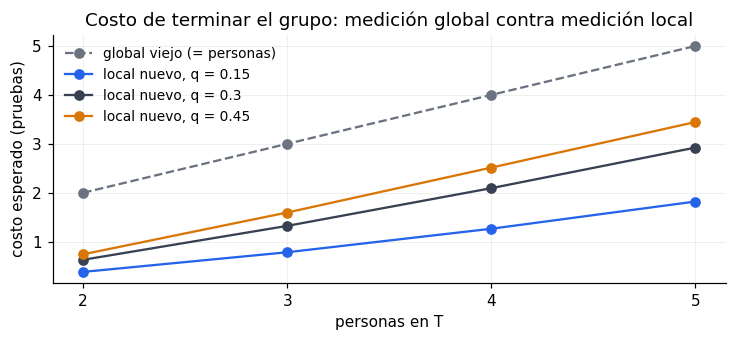

In [6]:
fig, ax = plt.subplots(figsize=(6.8, 3.2))
ms = [2, 3, 4, 5]
ax.plot(ms, ms, color=GRIS, ls='--', marker='o', label='global viejo (= personas)')
for q, c in zip((0.15, 0.30, 0.45), (AZUL, TINTA, AMBAR)):
    sub = nuevo[nuevo.q == q]
    ax.plot(sub.personas, sub['subpruebas tras la global'], marker='o', color=c,
            label=f'local nuevo, q = {q}')
ax.set_xlabel('personas en T'); ax.set_ylabel('costo esperado (pruebas)')
ax.set_xticks(ms); ax.legend(frameon=False, fontsize=9)
ax.set_title('Costo de terminar el grupo: medición global contra medición local')
plt.tight_layout(); plt.show()

**Lectura.** El costo local separa lo que la medición global aplastaba: crece
con el grupo pero por debajo de m, y distingue las prevalencias entre sí. El
conteo de la prueba global ya hace trabajo (los casos extremos terminan solos),
y eso es exactamente lo que la medición global no veía.

## 3.  q = 0.7, bajo el costo local

Cuánto cuesta de verdad terminar el grupo, y si cabe en el
presupuesto.

Con q = 0.7 el costo local total del grupo supera 1, así que la
"tijera" C ≤ b filtra grupos con ventaja positiva justo cuando el presupuesto es
apenas suficiente 

In [7]:
from augmented.laminar_benchmarks import ExactPolicyEvaluator

def valor_realizable(m, b, q, u=1.0):
    '''Optimo exacto extraible de una subpoblacion fresca de m personas con b pruebas.'''
    if m == 0 or b == 0:
        return 0.0
    ev = ExactPolicyEvaluator([1 - q] * m, [u] * m, b, m)
    return ev.optimal_value()

Q7 = 0.7
costo7 = {m: costo_local_exacto(m, Q7) for m in (2, 3, 4)}
comp = []
for m in (2, 3, 4):
    for b in (1, 2, 3):
        v_grupo = valor_realizable(m, b, Q7)
        v_single = min(b, m) * Q7
        comp.append({'personas': m, 'presupuesto': b,
                     'ventaja del grupo': v_grupo - v_single,
                     'costo local total': 1 + costo7[m],
                     'cabe (tijera)': 1 + costo7[m] <= b})
cq = pd.DataFrame(comp)
print(cq.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Autoverificacion: el valor realizable es monotono en el presupuesto,
# y con q>0.5 el paso goloso si agrupa.
for m in (2, 3, 4):
    vs = [valor_realizable(m, b, Q7) for b in (1, 2, 3)]
    assert vs[0] <= vs[1] <= vs[2] + 1e-12
assert tamano_pool_greedy(Q7) > 1
print('\nOK: realizable monotono en b, y greedy agrupa con q=0.7')

 personas  presupuesto  ventaja del grupo  costo local total  cabe (tijera)
        2            1             0.2800             1.6300          False
        2            2             0.0000             1.6300           True
        2            3             0.0000             1.6300           True
        3            1             0.3290             2.4070          False
        3            2             0.2800             2.4070          False
        3            3             0.0000             2.4070           True
        4            1             0.3290             3.2617          False
        4            2             0.5600             3.2617          False
        4            3             0.4858             3.2617          False

OK: realizable monotono en b, y greedy agrupa con q=0.7


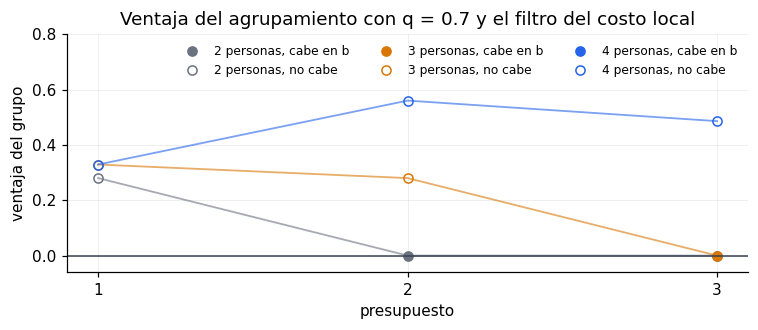

In [8]:
fig, ax = plt.subplots(figsize=(7.0, 3.1))
for m, c in zip((2, 3, 4), (GRIS, AMBAR, AZUL)):
    sub = cq[cq.personas == m]
    dentro = sub[sub['cabe (tijera)']]
    fuera = sub[~sub['cabe (tijera)']]
    ax.plot(sub.presupuesto, sub['ventaja del grupo'], color=c, lw=1.2, alpha=0.6)
    ax.plot(dentro.presupuesto, dentro['ventaja del grupo'], 'o', color=c,
            label=f'{m} personas, cabe en b')
    ax.plot(fuera.presupuesto, fuera['ventaja del grupo'], 'o', color=c,
            mfc='none', label=f'{m} personas, no cabe')
ax.axhline(0, color=TINTA, lw=1)
ax.set_ylim(-0.06, 0.80)
ax.set_xlabel('presupuesto'); ax.set_ylabel('ventaja del grupo')
ax.set_xticks([1, 2, 3]); ax.legend(frameon=False, fontsize=8, ncol=3)
ax.set_title('Ventaja del agrupamiento con q = 0.7 y el filtro del costo local')
plt.tight_layout(); plt.show()